# DSO3 Forecasting — Latence & Débit (MAE)

Notebook pour l'objectif **DSO3: Forecasting** :
- Prédire la latence et le débit
- Minimiser la **MAE**
- Anticiper les violations SLA (ex: latence > 20ms)
- Modèles avancés: **PyTorch**

## Plan
1. Chargement et validation des données (`network_qoe_latest.csv`)
2. Feature engineering temporel (lags, rolling, time features)
3. Baseline forecasting (RandomForest / XGBoost si dispo)
4. Forecasting avancé (LSTM **PyTorch**)
5. Évaluation MAE + prévision proactive des violations SLA

In [15]:
# Imports
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler

# XGBoost optionnel
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# PyTorch optionnel pour GRU
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

print(f'XGBoost disponible: {HAS_XGB}')
print(f'PyTorch disponible: {HAS_TORCH}')

XGBoost disponible: True
PyTorch disponible: True


In [16]:
# Localisation du CSV (placé dans le dossier data)
CSV_PATH = Path("../../../data/network_qoe_latest.csv").resolve()

candidates = [
    CSV_PATH,
    Path('network_qoe_latest.csv'),
    Path('../../network_qoe_latest.csv'),
    Path('../../../network_qoe_latest.csv'),
    Path('../../../../network_qoe_latest.csv'),
    Path('../../../../data/network_qoe_latest.csv'),
]

for p in candidates:
    if p.exists():
        CSV_PATH = p.resolve()
        break

if CSV_PATH is None or not CSV_PATH.exists():
    raise FileNotFoundError(
        'network_qoe_latest.csv introuvable. Place le fichier dans le dossier data '
        'ou corrige CSV_PATH dans cette cellule.'
    )

print('CSV utilisé:', CSV_PATH)
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

CSV utilisé: C:\Users\Dell\Desktop\Esprit-PI-4DS9-2526-QoSentry\data\network_qoe_latest.csv
Shape: (93276, 33)


,run_id,timestamp,datetime,segment,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,...,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count,mos_source,label
0,run_20260325_115425,1.774436e+09,11:45:53,INTERNET,1,4,4.398,10.942,0.0,1.2151,...,98,0,1,0,0,NaN,10.942,0,ctrl_plane_fallback,NORMAL
1,run_20260325_115425,1.774436e+09,11:45:53,OUTDOOR_RAN,1,1,4.398,10.942,0.0,1.2151,...,98,1,1,0,0,NaN,10.942,0,ctrl_plane_fallback,NORMAL
2,run_20260325_115425,1.774436e+09,11:45:53,INDOOR_RAN,1,2,4.398,10.942,0.0,1.2151,...,98,0,1,0,0,NaN,10.942,0,ctrl_plane_fallback,NORMAL
3,run_20260325_115425,1.774436e+09,11:45:53,IMS_CDN,1,3,4.398,10.942,0.0,1.2151,...,98,1,1,0,0,NaN,10.942,0,ctrl_plane_fallback,NORMAL
4,run_20260325_115425,1.774436e+09,11:45:55,INTERNET,1,4,4.394,18.291,0.0,1.5985,...,98,0,1,0,0,NaN,18.291,0,ctrl_plane_fallback,NORMAL


In [17]:
# Détection automatique des colonnes clés
possible_datetime = ['datetime', 'timestamp', 'time', 'date']
possible_latency = ['e2e_delay_ms', 'dataplane_latency_ms', 'latency_ms']
possible_throughput = ['throughput_mbps', 'throughput', 'bw_mbps']

def pick_col(possible, columns):
    for c in possible:
        if c in columns:
            return c
    return None

datetime_col = pick_col(possible_datetime, df.columns)
latency_col = pick_col(possible_latency, df.columns)
throughput_col = pick_col(possible_throughput, df.columns)

if datetime_col is None:
    raise ValueError('Aucune colonne datetime trouvée (attendu: datetime/timestamp/time/date).')
if latency_col is None:
    raise ValueError('Aucune colonne latence trouvée (attendu: e2e_delay_ms ou dataplane_latency_ms).')
if throughput_col is None:
    raise ValueError('Aucune colonne débit trouvée (attendu: throughput_mbps).')

df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
df = df.dropna(subset=[datetime_col]).sort_values(datetime_col).reset_index(drop=True)

print('datetime_col :', datetime_col)
print('latency_col  :', latency_col)
print('throughput_col:', throughput_col)
print('Rows valides  :', len(df))

datetime_col : datetime
latency_col  : e2e_delay_ms
throughput_col: throughput_mbps
Rows valides  : 93276


In [18]:
# Features temporelles cycliques + RobustScaler (anti-outliers)
df['hour'] = df[datetime_col].dt.hour
df['minute'] = df[datetime_col].dt.minute
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

features_to_scale = [latency_col, throughput_col, 'hour_sin', 'hour_cos']

split_idx_df = int(len(df) * 0.8)
scaler = RobustScaler()
train_data = df.iloc[:split_idx_df][features_to_scale]
test_data = df.iloc[split_idx_df:][features_to_scale]

df.loc[:split_idx_df-1, features_to_scale] = scaler.fit_transform(train_data)
df.loc[split_idx_df:, features_to_scale] = scaler.transform(test_data)

print('RobustScaler appliqué sur:', features_to_scale)

RobustScaler appliqué sur: ['e2e_delay_ms', 'throughput_mbps', 'hour_sin', 'hour_cos']


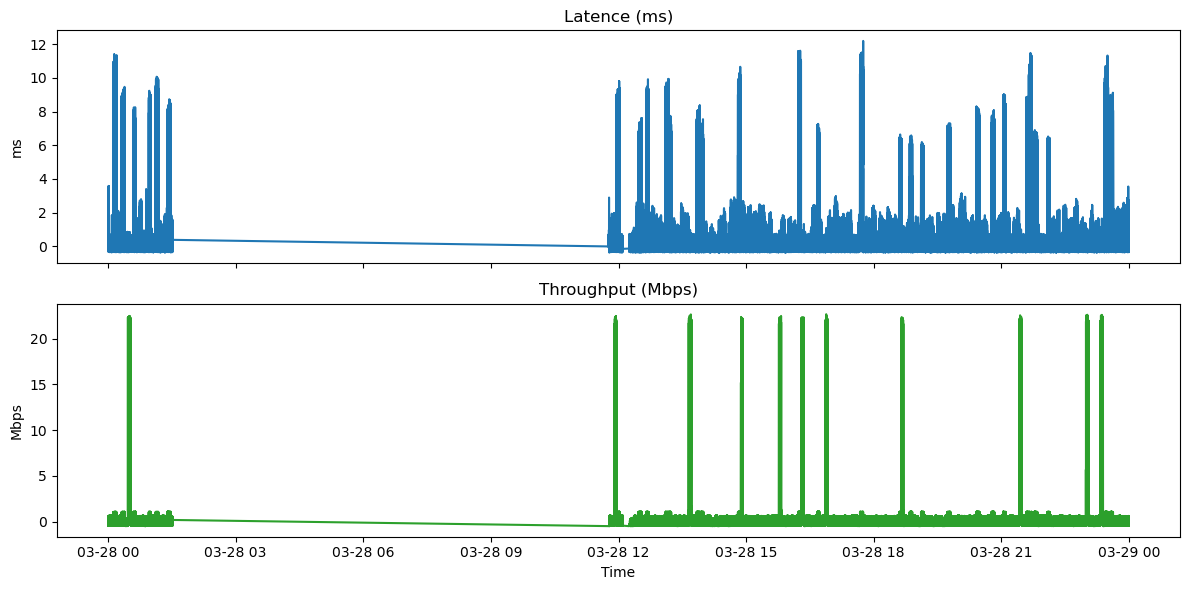

In [19]:
# Visualisation des series temporelles principales
plot_df = df[[datetime_col, latency_col, throughput_col]].copy()
plot_df = plot_df.dropna().sort_values(datetime_col)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(plot_df[datetime_col], plot_df[latency_col], color='tab:blue')
axes[0].set_title('Latence (ms)')
axes[0].set_ylabel('ms')

axes[1].plot(plot_df[datetime_col], plot_df[throughput_col], color='tab:green')
axes[1].set_title('Throughput (Mbps)')
axes[1].set_ylabel('Mbps')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

In [20]:
# Feature engineering temporel
work = df[[datetime_col, latency_col, throughput_col] + [c for c in ['label', 'segment'] if c in df.columns]].copy()

# Targets (horizon 1 pas de temps)
horizon = 1
work['target_latency'] = work[latency_col].shift(-horizon)
work['target_throughput'] = work[throughput_col].shift(-horizon)

# Lags
lags = [1, 2, 3, 5, 10]
for lag in lags:
    work[f'{latency_col}_lag_{lag}'] = work[latency_col].shift(lag)
    work[f'{throughput_col}_lag_{lag}'] = work[throughput_col].shift(lag)

# Rolling windows
windows = [5, 10]
for w in windows:
    work[f'{latency_col}_roll_mean_{w}'] = work[latency_col].rolling(w).mean()
    work[f'{latency_col}_roll_std_{w}'] = work[latency_col].rolling(w).std()
    work[f'{throughput_col}_roll_mean_{w}'] = work[throughput_col].rolling(w).mean()
    work[f'{throughput_col}_roll_std_{w}'] = work[throughput_col].rolling(w).std()

# Time features (incluant cycles)
work['hour'] = df['hour']
work['minute'] = df['minute']
work['second'] = df[datetime_col].dt.second
work['dayofweek'] = df[datetime_col].dt.dayofweek
work['hour_sin'] = df['hour_sin']
work['hour_cos'] = df['hour_cos']

# Encodage léger de segment (si présent)
if 'segment' in work.columns:
    work['segment_code'] = work['segment'].astype('category').cat.codes

# Nettoyage NA liés aux décalages
work = work.dropna().reset_index(drop=True)
print('Shape après feature engineering:', work.shape)
work.head()

Shape après feature engineering: (93265, 32)


,datetime,e2e_delay_ms,throughput_mbps,label,segment,target_latency,target_throughput,e2e_delay_ms_lag_1,throughput_mbps_lag_1,e2e_delay_ms_lag_2,...,e2e_delay_ms_roll_std_10,throughput_mbps_roll_mean_10,throughput_mbps_roll_std_10,hour,minute,second,dayofweek,hour_sin,hour_cos,segment_code
0,2026-03-28 00:00:05,2.388416,0.292305,POOR_VOICE_QUALITY,INDOOR_RAN,-0.084316,-0.280415,-0.316900,-0.420379,-0.009204,...,1.172247,0.022103,0.423849,0,0,5,5,1.0,0.921519,1
1,2026-03-28 00:00:05,-0.084316,-0.280415,POOR_VOICE_QUALITY,OUTDOOR_RAN,-0.009204,0.605083,2.388416,0.292305,-0.316900,...,1.060957,-0.034813,0.422277,0,0,5,5,1.0,0.921519,3
2,2026-03-28 00:00:07,-0.009204,0.605083,POOR_VOICE_QUALITY,IMS_CDN,-0.296324,-0.431232,-0.084316,-0.280415,2.388416,...,1.044424,0.068012,0.441937,0,0,7,5,1.0,0.921519,0
3,2026-03-28 00:00:07,-0.296324,-0.431232,POOR_VOICE_QUALITY,INTERNET,2.388416,0.309614,-0.009204,0.605083,-0.084316,...,1.057734,0.053431,0.457042,0,0,7,5,1.0,0.921519,2
4,2026-03-28 00:00:07,2.388416,0.309614,POOR_VOICE_QUALITY,INDOOR_RAN,-0.118381,-0.295479,-0.296324,-0.431232,-0.009204,...,1.214574,0.126961,0.429729,0,0,7,5,1.0,0.921519,1


In [21]:
# Baseline setup (split)
exclude_cols = [datetime_col, 'target_latency', 'target_throughput', 'label', 'segment']
feature_cols = [c for c in work.columns if c not in exclude_cols]

X = work[feature_cols]
y_lat = work['target_latency']
y_thr = work['target_throughput']

split_idx = int(len(work) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_lat_train, y_lat_test = y_lat.iloc[:split_idx], y_lat.iloc[split_idx:]
y_thr_train, y_thr_test = y_thr.iloc[:split_idx], y_thr.iloc[split_idx:]

results = []
rf_lat_pred = None
rf_thr_pred = None
xgb_lat_pred = None
xgb_thr_pred = None

### Baseline 1: Naive (last value)

In [22]:
naive_lat_pred = work[latency_col].iloc[split_idx:split_idx+len(y_lat_test)].values
naive_thr_pred = work[throughput_col].iloc[split_idx:split_idx+len(y_thr_test)].values
naive_lat_mae = mean_absolute_error(y_lat_test, naive_lat_pred)
naive_thr_mae = mean_absolute_error(y_thr_test, naive_thr_pred)

results.append({
    'model': 'Naive(last value)',
    'MAE_latency_ms': naive_lat_mae,
    'MAE_throughput_mbps': naive_thr_mae
})

print('Naive MAE latency:', round(naive_lat_mae, 4))
print('Naive MAE throughput:', round(naive_thr_mae, 4))

Naive MAE latency: 1.0885
Naive MAE throughput: 1.1572


### Baseline 2: RandomForest (training)

In [23]:
rf_estimators = 300
rf_step = 50

rf_lat = RandomForestRegressor(n_estimators=rf_step, random_state=42, n_jobs=-1, warm_start=True)
rf_thr = RandomForestRegressor(n_estimators=rf_step, random_state=42, n_jobs=-1, warm_start=True)

for n in range(rf_step, rf_estimators + 1, rf_step):
    rf_lat.set_params(n_estimators=n)
    rf_lat.fit(X_train, y_lat_train)
    print(f'RF latency trees: {n}/{rf_estimators}')

    rf_thr.set_params(n_estimators=n)
    rf_thr.fit(X_train, y_thr_train)
    print(f'RF throughput trees: {n}/{rf_estimators}')

RF latency trees: 50/300
RF throughput trees: 50/300
RF latency trees: 100/300
RF throughput trees: 100/300
RF latency trees: 150/300
RF throughput trees: 150/300
RF latency trees: 200/300
RF throughput trees: 200/300
RF latency trees: 250/300
RF throughput trees: 250/300
RF latency trees: 300/300
RF throughput trees: 300/300


### RandomForest (prediction + MAE)

In [24]:
rf_lat_pred = rf_lat.predict(X_test)
rf_thr_pred = rf_thr.predict(X_test)
rf_lat_mae = mean_absolute_error(y_lat_test, rf_lat_pred)
rf_thr_mae = mean_absolute_error(y_thr_test, rf_thr_pred)

results.append({
    'model': 'RandomForest',
    'MAE_latency_ms': rf_lat_mae,
    'MAE_throughput_mbps': rf_thr_mae
})

print('RF MAE latency:', round(rf_lat_mae, 4))
print('RF MAE throughput:', round(rf_thr_mae, 4))

RF MAE latency: 0.4598
RF MAE throughput: 0.4859


### Baseline 3: XGBoost (training)

In [25]:
if HAS_XGB:
    xgb_lat = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbosity=1
    )
    xgb_thr = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbosity=1
    )

    print('XGB training (latency)...')
    xgb_lat.fit(X_train, y_lat_train, eval_set=[(X_test, y_lat_test)], verbose=True)
    print('XGB training (throughput)...')
    xgb_thr.fit(X_train, y_thr_train, eval_set=[(X_test, y_thr_test)], verbose=True)
else:
    print('XGBoost non installé: étape ignorée.')

XGB training (latency)...
[0]	validation_0-rmse:1.97657
[1]	validation_0-rmse:1.90615
[2]	validation_0-rmse:1.83814
[3]	validation_0-rmse:1.77313
[4]	validation_0-rmse:1.71668
[5]	validation_0-rmse:1.66226
[6]	validation_0-rmse:1.60854
[7]	validation_0-rmse:1.56602
[8]	validation_0-rmse:1.52190
[9]	validation_0-rmse:1.48098
[10]	validation_0-rmse:1.44309
[11]	validation_0-rmse:1.40849
[12]	validation_0-rmse:1.38120
[13]	validation_0-rmse:1.34820
[14]	validation_0-rmse:1.32016
[15]	validation_0-rmse:1.29441
[16]	validation_0-rmse:1.26996
[17]	validation_0-rmse:1.24628
[18]	validation_0-rmse:1.22603
[19]	validation_0-rmse:1.20978
[20]	validation_0-rmse:1.19314
[21]	validation_0-rmse:1.17705
[22]	validation_0-rmse:1.16338
[23]	validation_0-rmse:1.15126
[24]	validation_0-rmse:1.13897
[25]	validation_0-rmse:1.12789
[26]	validation_0-rmse:1.11800
[27]	validation_0-rmse:1.10756
[28]	validation_0-rmse:1.09952
[29]	validation_0-rmse:1.09215
[30]	validation_0-rmse:1.08481
[31]	validation_0-rmse:

### XGBoost (prediction + MAE)

In [26]:
if HAS_XGB:
    xgb_lat_pred = xgb_lat.predict(X_test)
    xgb_thr_pred = xgb_thr.predict(X_test)
    xgb_lat_mae = mean_absolute_error(y_lat_test, xgb_lat_pred)
    xgb_thr_mae = mean_absolute_error(y_thr_test, xgb_thr_pred)

    results.append({
        'model': 'XGBoost',
        'MAE_latency_ms': xgb_lat_mae,
        'MAE_throughput_mbps': xgb_thr_mae
    })

    print('XGB MAE latency:', round(xgb_lat_mae, 4))
    print('XGB MAE throughput:', round(xgb_thr_mae, 4))

XGB MAE latency: 0.4664
XGB MAE throughput: 0.5507


### Comparaison des MAE (baseline)

In [27]:
results_df = pd.DataFrame(results).sort_values('MAE_latency_ms')
results_df

,model,MAE_latency_ms,MAE_throughput_mbps
1,RandomForest,0.459849,0.485915
2,XGBoost,0.466431,0.550723
0,Naive(last value),1.088522,1.157158


In [28]:
# GRU (PyTorch) + RobustScaler + Scheduler
lstm_summary = None
if HAS_TORCH:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    seq_length = 20
    num_epochs = 100

    # Mise a l'echelle robuste
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    X_scaled = scaler_X.fit_transform(X.values)
    y_scaled = scaler_y.fit_transform(y_lat.values.reshape(-1, 1)).ravel()

    # Creation des sequences
    def create_sequences(data_X, data_y, seq_length):
        X_seq, y_seq = [], []
        for i in range(len(data_X) - seq_length):
            X_seq.append(data_X[i:(i + seq_length)])
            y_seq.append(data_y[i + seq_length])
        return np.array(X_seq), np.array(y_seq)

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

    split_seq = int(len(X_seq) * 0.8)
    Xs_train, Xs_test = X_seq[:split_seq], X_seq[split_seq:]
    ys_train, ys_test = y_seq[:split_seq], y_seq[split_seq:]

    train_ds = TensorDataset(
        torch.tensor(Xs_train, dtype=torch.float32),
        torch.tensor(ys_train, dtype=torch.float32).unsqueeze(-1)
    )
    test_ds = TensorDataset(
        torch.tensor(Xs_test, dtype=torch.float32),
        torch.tensor(ys_test, dtype=torch.float32).unsqueeze(-1)
    )
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    class RobustQoEForecaster(nn.Module):
        def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.3):
            super().__init__()
            self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
            self.fc = nn.Linear(hidden_dim, output_dim)

        def forward(self, x):
            out, _ = self.gru(x)
            out = out[:, -1, :]
            return self.fc(out)

    model = RobustQoEForecaster(input_dim=Xs_train.shape[2]).to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

    # Entrainement + validation
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += criterion(preds, yb).item()
        val_loss /= len(test_loader)

        scheduler.step(val_loss)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] - Train MAE: {train_loss:.4f} - Val MAE: {val_loss:.4f}')

    # Prediction
    model.eval()
    preds_list = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            preds_list.append(model(xb).cpu().numpy().ravel())

    ys_pred_scaled = np.concatenate(preds_list)
    ys_test_real = scaler_y.inverse_transform(ys_test.reshape(-1, 1)).ravel()
    ys_pred_real = scaler_y.inverse_transform(ys_pred_scaled.reshape(-1, 1)).ravel()

    lstm_mae = mean_absolute_error(ys_test_real, ys_pred_real)
    lstm_summary = {'model': 'GRU(latency only, PyTorch)', 'MAE_latency_ms': lstm_mae}
    print('GRU MAE (latency):', round(lstm_mae, 4))
else:
    print('PyTorch non installé: étape GRU ignorée.')

lstm_summary

Epoch [10/100] - Train MAE: 0.5545 - Val MAE: 0.5848
Epoch [20/100] - Train MAE: 0.5379 - Val MAE: 0.5694
Epoch [30/100] - Train MAE: 0.5192 - Val MAE: 0.5289
Epoch [40/100] - Train MAE: 0.4997 - Val MAE: 0.5278
Epoch [50/100] - Train MAE: 0.4830 - Val MAE: 0.5231
Epoch [60/100] - Train MAE: 0.4762 - Val MAE: 0.5263
Epoch [70/100] - Train MAE: 0.4723 - Val MAE: 0.5208
Epoch [80/100] - Train MAE: 0.4699 - Val MAE: 0.5219
Epoch [90/100] - Train MAE: 0.4721 - Val MAE: 0.5198
Epoch [100/100] - Train MAE: 0.4689 - Val MAE: 0.5207
GRU MAE (latency): 0.503


{'model': 'GRU(latency only, PyTorch)', 'MAE_latency_ms': 0.5029991753028213}

In [29]:
# Prévision des violations SLA (latence)
# Règle exemple: violation si latence future > 20 ms
SLA_LATENCY_THRESHOLD_MS = 20.0

# On prend la meilleure prédiction de latence disponible entre XGB et RF
if HAS_XGB and xgb_lat_pred is not None:
    pred_latency = xgb_lat_pred
    model_name = 'XGBoost'
else:
    pred_latency = rf_lat_pred
    model_name = 'RandomForest'

actual_violation = (y_lat_test.values > SLA_LATENCY_THRESHOLD_MS).astype(int)
pred_violation = (pred_latency > SLA_LATENCY_THRESHOLD_MS).astype(int)

cm = confusion_matrix(actual_violation, pred_violation)
print(f'Modèle utilisé pour alerte SLA: {model_name}')
print('Matrice de confusion [TN FP; FN TP]:')
print(cm)
print('\nRapport de classification:')
print(classification_report(actual_violation, pred_violation, digits=4))

alerts = pd.DataFrame({
    'datetime': work[datetime_col].iloc[split_idx:].values,
    'latency_actual_t+1': y_lat_test.values,
    'latency_pred_t+1': pred_latency,
    'actual_violation': actual_violation,
    'pred_violation': pred_violation
})

# Si segment/label présents, les joindre pour analyse par type de trafic
for c in ['segment', 'label']:
    if c in work.columns:
        alerts[c] = work[c].iloc[split_idx:].values

alerts.head(10)

Modèle utilisé pour alerte SLA: XGBoost
Matrice de confusion [TN FP; FN TP]:
[[18653]]

Rapport de classification:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     18653

    accuracy                         1.0000     18653
   macro avg     1.0000    1.0000    1.0000     18653
weighted avg     1.0000    1.0000    1.0000     18653



,datetime,latency_actual_t+1,latency_pred_t+1,actual_violation,pred_violation,segment,label
0,2026-03-28 21:17:01,-0.030733,-0.080941,0,0,INDOOR_RAN,NORMAL
1,2026-03-28 21:17:01,-0.107326,0.040061,0,0,IMS_CDN,NORMAL
2,2026-03-28 21:17:03,-0.127903,0.279061,0,0,IMS_CDN,NORMAL
3,2026-03-28 21:17:03,-0.065168,0.015405,0,0,INTERNET,NORMAL
4,2026-03-28 21:17:03,0.575509,0.547957,0,0,OUTDOOR_RAN,NORMAL
5,2026-03-28 21:17:03,-0.304205,-0.000801,0,0,INDOOR_RAN,NORMAL
6,2026-03-28 21:17:05,-0.065168,0.007001,0,0,INTERNET,NORMAL
7,2026-03-28 21:17:05,0.575509,0.481491,0,0,OUTDOOR_RAN,NORMAL
8,2026-03-28 21:17:05,-0.107326,-0.031357,0,0,INDOOR_RAN,NORMAL
9,2026-03-28 21:17:05,0.575509,0.050855,0,0,IMS_CDN,NORMAL


## Interprétation et prochaines actions
- La métrique principale est la **MAE** (latence en ms et débit en Mbps).
- Conserver le modèle avec la MAE la plus faible sur le split temporel.
- Ajuster `horizon`, `lags`, `windows`, et les hyperparamètres pour améliorer la robustesse.
- Pour production: validation croisée temporelle + monitoring dérive + recalibrage périodique.